In [3]:
import fastf1
import fastf1.plotting
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# キャッシュの有効化
fastf1.Cache.enable_cache('cache')

# 2026年オーストラリアGPの決勝(R)データをロード
session = fastf1.get_session(2026, 'Australia', 'R')
session.load()

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 81
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '12', '16', '44', '1

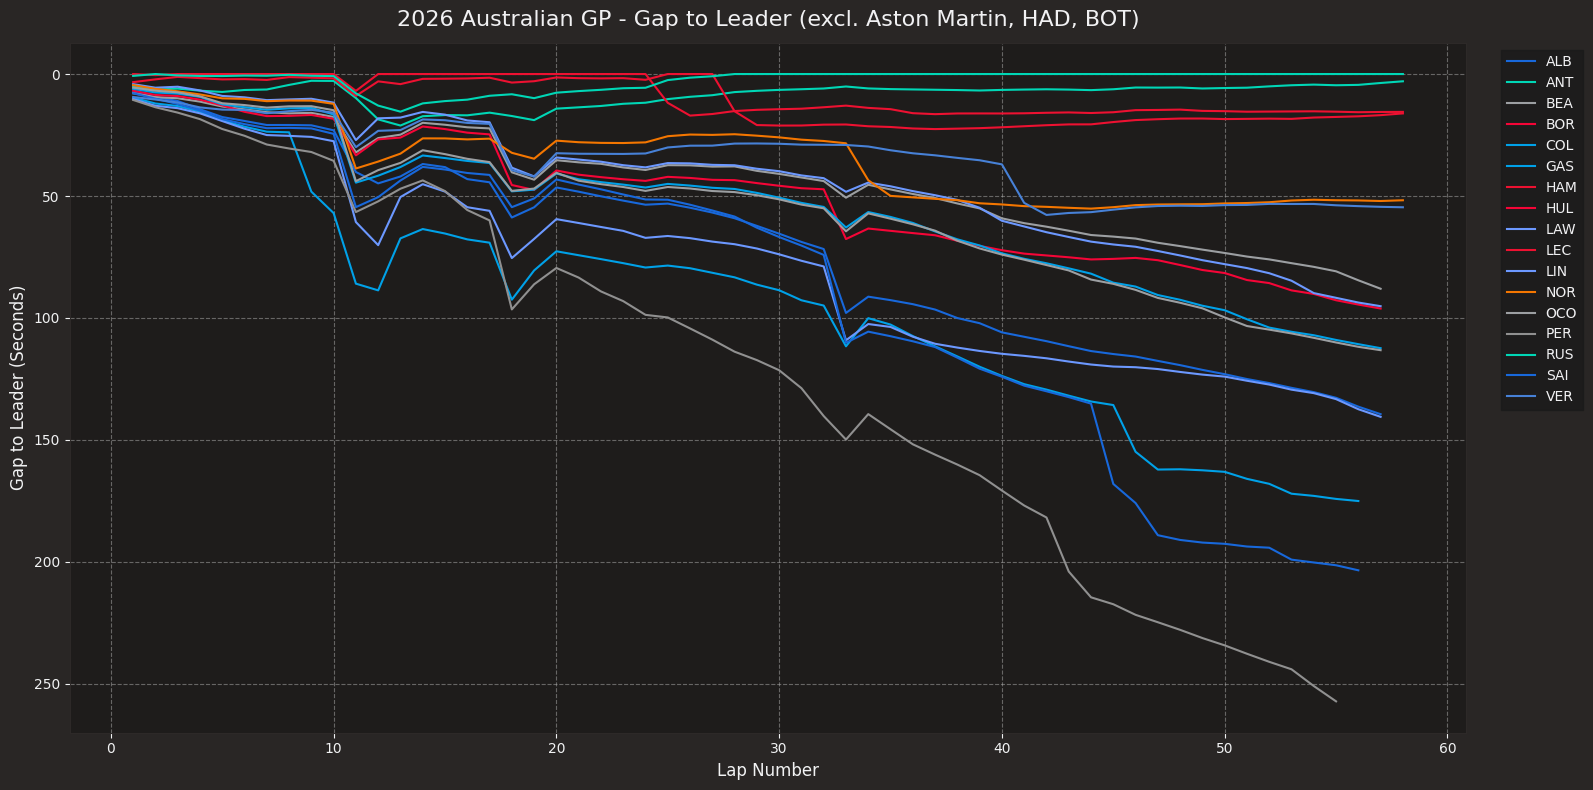

In [6]:
# ★ここが変更点：特定チームと特定ドライバーの除外設定★
# 最初から除外したいドライバー（HAD, BOT）をリストに入れておく
exclude_drivers = ['HAD', 'BOT'] 
driver_colors = {}

# session.results（公式のリザルトデータ）から各ドライバーの情報を取得
for _, row in session.results.iterrows():
    driver = row['Abbreviation']
    team_name = row['TeamName']
    team_color = row['TeamColor']
    
    # チーム名に 'Aston Martin' が含まれる場合は除外リストに追加
    if pd.notna(team_name) and 'Aston Martin' in str(team_name):
        if driver not in exclude_drivers: # リストの重複を防ぐ
            exclude_drivers.append(driver)
        continue 

    # カラー情報がない場合は白にする
    if pd.isna(team_color) or team_color == '':
        driver_colors[driver] = 'white'
    else:
        driver_colors[driver] = f"#{team_color}" # 16進数カラーコード

# ===== ここからグラフ描画 =====
plt.figure(figsize=(16, 8))

for driver in gaps_seconds.columns:
    # 除外リスト（アストンマーチン、HAD、BOT）に入っていたらプロットをスキップ
    if driver in exclude_drivers:
        continue

    # 先ほど作った辞書から色を取得
    color = driver_colors.get(driver, 'white')
        
    plt.plot(gaps_seconds.index, gaps_seconds[driver], label=driver, color=color, linewidth=1.5)

# タイトルも少し変更しておきます
plt.title('2026 Australian GP - Gap to Leader (excl. Aston Martin, HAD, BOT)', fontsize=16)
plt.xlabel('Lap Number', fontsize=12)
plt.ylabel('Gap to Leader (Seconds)', fontsize=12)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left') 
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Y軸を反転
plt.gca().invert_yaxis() 

plt.show()

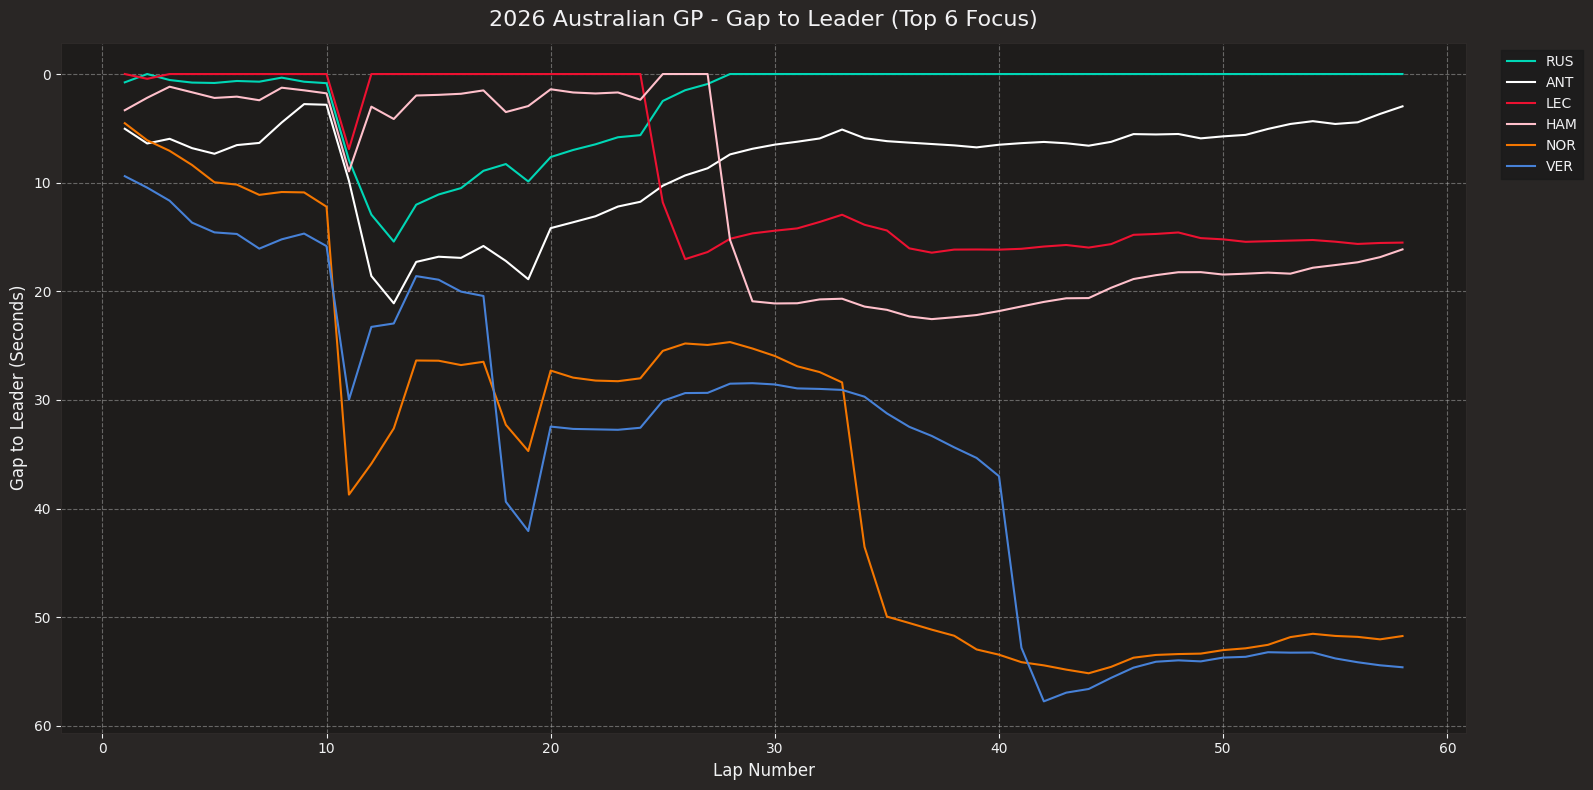

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# ★ここが変更点：見たい6名のドライバーだけをリストで指定する★
target_drivers = ['RUS', 'ANT', 'LEC', 'HAM', 'NOR', 'VER']

# ハミルトンとアントネッリのカスタムカラー設定
custom_colors = {
    'ANT': 'white',  # アントネッリを白に
    'HAM': 'pink'    # ハミルトンをピンクに
}

driver_colors = {}

# session.results（公式のリザルトデータ）から各ドライバーの情報を取得
for _, row in session.results.iterrows():
    driver = row['Abbreviation']
    
    # ターゲットドライバー以外は色取得の処理をスキップ
    if driver not in target_drivers:
        continue
        
    # カスタムカラーが設定されている場合はそれを優先
    if driver in custom_colors:
        driver_colors[driver] = custom_colors[driver]
    else:
        team_color = row['TeamColor']
        if pd.isna(team_color) or team_color == '':
            driver_colors[driver] = 'white'
        else:
            driver_colors[driver] = f"#{team_color}" # 16進数カラーコード

# ===== ここからグラフ描画 =====
plt.figure(figsize=(16, 8))

# target_driversのリストに入っているドライバーだけをループで回す
for driver in target_drivers:
    # 万が一データに存在しないドライバーがいた場合のエラー回避
    if driver in gaps_seconds.columns:
        # 先ほど作った辞書から色を取得
        color = driver_colors.get(driver, 'white')
            
        plt.plot(gaps_seconds.index, gaps_seconds[driver], label=driver, color=color, linewidth=1.5)

# タイトルを分かりやすく変更
plt.title('2026 Australian GP - Gap to Leader (Top 6 Focus)', fontsize=16)
plt.xlabel('Lap Number', fontsize=12)
plt.ylabel('Gap to Leader (Seconds)', fontsize=12)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left') 
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Y軸を反転（0秒のトップが一番上になるように）
plt.gca().invert_yaxis() 

plt.show()

/Users/kazuma/F1_NEW_Analysis_/.venv/lib/python3.10/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/Users/kazuma/F1_NEW_Analysis_/.venv/lib/python3.10/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/Users/kazuma/F1_NEW_Analysis_/.venv/lib/python3.10/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/Users/kazuma/F1_NEW_Analysis_/.venv/lib/python3.10/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_dr

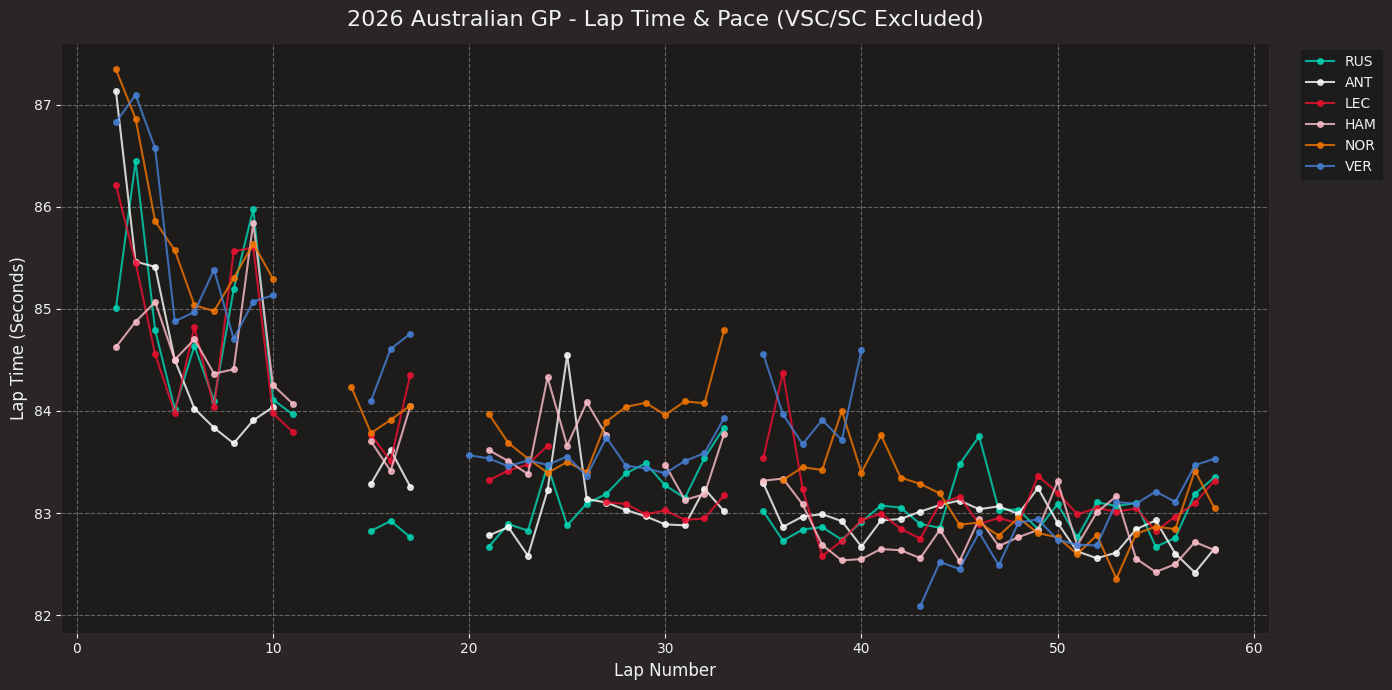

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 分析したいドライバーのリストを指定
target_drivers = ['RUS', 'ANT', 'LEC', 'HAM', 'NOR', 'VER']

# ★ここが追加点：特定ドライバーのカスタムカラー指定★
# 辞書型で、ドライバーの略称と適用したい色をセットにします
custom_colors = {
    'HAM': 'pink',   # ハミルトンをピンク色に変更
    'ANT': 'white'    # アントネッリを白に変更（お好みで 'yellow' 等に変更可能です）
}

plt.figure(figsize=(14, 7))

for driver in target_drivers:
    # 1. 特定ドライバーの全ラップを取得し、警告を防ぐためにコピーを作成
    driver_laps = session.laps.pick_driver(driver).copy()
    
    # 2. タイムを「秒」に変換して新しい列を作成
    driver_laps['LapTime_sec'] = driver_laps['LapTime'].dt.total_seconds()
    
    # 線を切断する（空白にする）ためのマスク処理
    is_vsc_sc = driver_laps['TrackStatus'].str.contains('4|5|6', na=False)
    is_inaccurate = ~driver_laps['IsAccurate']
    driver_laps.loc[is_vsc_sc | is_inaccurate, 'LapTime_sec'] = np.nan
    
    # 3. カラーの取得（★カスタムカラー設定があればそれを優先する処理に変更★）
    if driver in custom_colors:
        color = custom_colors[driver]
    else:
        try:
            team_color = session.results.loc[session.results['Abbreviation'] == driver, 'TeamColor'].values[0]
            color = f"#{team_color}" if pd.notna(team_color) and team_color != '' else 'white'
        except:
            color = 'white'

    # 4. スティントごとにプロット
    for stint, stint_data in driver_laps.groupby('Stint'):
        # リタイア後など、スティント情報がないデータはスキップ
        if pd.isna(stint):
            continue
            
        lap_numbers = stint_data['LapNumber']
        lap_times = stint_data['LapTime_sec']
        
        label = driver if stint == 1 else ""
        
        # NaNが含まれているため、VSCやピットの箇所で自動的に線が切れて描画されます
        plt.plot(lap_numbers, lap_times, label=label, color=color, 
                 marker='o', markersize=4, linewidth=1.5, alpha=0.8)

plt.title('2026 Australian GP - Lap Time & Pace (VSC/SC Excluded)', fontsize=16)
plt.xlabel('Lap Number', fontsize=12)
plt.ylabel('Lap Time (Seconds)', fontsize=12)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

In [12]:
import pandas as pd
import numpy as np
from IPython.display import display

target_drivers = ['RUS', 'ANT', 'LEC', 'HAM', 'NOR', 'VER']
stint_data_list = []

for driver in target_drivers:
    driver_laps = session.laps.pick_driver(driver).copy()
    
    # スティントごとにデータをグループ化
    for stint, stint_laps in driver_laps.groupby('Stint'):
        if pd.isna(stint):
            continue
            
        # --- 基本情報の取得 ---
        compound = stint_laps['Compound'].iloc[0]
        stint_laps_count = len(stint_laps) # そのスティントで走った周回数
        
        # タイヤの寿命（TyreLife）。スタート時が1より大きければ中古（Used）
        tyre_life_start = stint_laps['TyreLife'].min()
        tyre_life_end = stint_laps['TyreLife'].max()
        tyre_condition = "New" if tyre_life_start == 1 else "Used"
        
        # --- ペースとデグラデーションの計算（VSCやピットイン等の異常値を除外） ---
        is_vsc_sc = stint_laps['TrackStatus'].str.contains('4|5|6', na=False)
        is_inaccurate = ~stint_laps['IsAccurate']
        valid_laps = stint_laps[~(is_vsc_sc | is_inaccurate)].copy()
        
        # 有効なラップが少なすぎる（3周未満など）場合は計算エラーを防ぐためNaNにする
        if len(valid_laps) < 3:
            avg_lap_time = np.nan
            deg_per_lap = np.nan
        else:
            valid_laps['LapTime_sec'] = valid_laps['LapTime'].dt.total_seconds()
            avg_lap_time = valid_laps['LapTime_sec'].mean()
            
            # デグラデーションの計算（線形回帰の傾きを求める）
            x = valid_laps['LapNumber'].values
            y = valid_laps['LapTime_sec'].values
            slope, _ = np.polyfit(x, y, 1) 
            deg_per_lap = slope # 1ラップあたり何秒タイムが変化したか

        # 集計リストにデータを追加
        stint_data_list.append({
            'Driver': driver,
            'Stint': int(stint),
            'Compound': compound,
            'Condition': tyre_condition,
            'Stint Laps': stint_laps_count,
            'Tyre Age (Start-End)': f"{int(tyre_life_start)} - {int(tyre_life_end)}",
            'Avg Pace (sec)': avg_lap_time,
            'Degradation (sec/lap)': deg_per_lap
        })

# データフレームに変換して見やすくフォーマット
df_stints = pd.DataFrame(stint_data_list)

# 小数点以下の桁数を調整
df_stints['Avg Pace (sec)'] = df_stints['Avg Pace (sec)'].round(3)
df_stints['Degradation (sec/lap)'] = df_stints['Degradation (sec/lap)'].round(4)

# Jupyter Notebook上で表を綺麗に表示
display(df_stints)

/Users/kazuma/F1_NEW_Analysis_/.venv/lib/python3.10/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/Users/kazuma/F1_NEW_Analysis_/.venv/lib/python3.10/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/Users/kazuma/F1_NEW_Analysis_/.venv/lib/python3.10/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/Users/kazuma/F1_NEW_Analysis_/.venv/lib/python3.10/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_dr

,Driver,Stint,Compound,Condition,Stint Laps,Tyre Age (Start-End),Avg Pace (sec),Degradation (sec/lap)
0,RUS,1,MEDIUM,New,12,1 - 12,84.824,-0.1016
1,RUS,2,HARD,New,46,1 - 46,83.060,0.0007
2,ANT,1,MEDIUM,New,12,1 - 12,84.665,-0.3525
3,ANT,2,HARD,New,46,1 - 46,82.992,-0.0136
4,LEC,1,MEDIUM,New,25,1 - 25,84.324,-0.0883
5,LEC,2,HARD,New,33,1 - 33,83.068,-0.0028
6,HAM,1,MEDIUM,New,28,1 - 28,84.211,-0.0502
7,HAM,2,HARD,New,30,1 - 30,82.875,-0.0226
8,NOR,1,MEDIUM,New,11,1 - 11,85.765,-0.2263
9,NOR,2,HARD,New,23,1 - 23,83.906,0.0140


In [13]:
import pandas as pd

# 2026年オーストラリアGPの「予選(Q)」データを新たにロード
session_q = fastf1.get_session(2026, 'Australia', 'Q')
session_q.load()

target_drivers = ['RUS', 'ANT', 'LEC', 'HAM', 'NOR', 'VER']
quali_data_list = []

for driver in target_drivers:
    try:
        # そのドライバーの予選での最速ラップを取得
        fastest_lap = session_q.laps.pick_driver(driver).pick_fastest()
        
        # テレメトリーデータ（速度推移など）を取得し、その周の絶対的な最高速を算出
        telemetry = fastest_lap.get_telemetry()
        max_speed = telemetry['Speed'].max()
        
        # 各データを抽出（タイムは秒に変換して扱いやすくする）
        lap_time = fastest_lap['LapTime'].total_seconds()
        s1_time = fastest_lap['Sector1Time'].total_seconds()
        s2_time = fastest_lap['Sector2Time'].total_seconds()
        s3_time = fastest_lap['Sector3Time'].total_seconds()
        speed_trap = fastest_lap['SpeedST'] # 公式のスピードトラップ地点での速度
        
        quali_data_list.append({
            'Driver': driver,
            'Lap Time': lap_time,
            'Sector 1': s1_time,
            'Sector 2': s2_time,
            'Sector 3': s3_time,
            'Speed Trap (km/h)': speed_trap,
            'Max Speed (km/h)': max_speed
        })
    except Exception as e:
        print(f"{driver}のデータ取得に失敗しました: {e}")

# データフレームに変換
df_quali = pd.DataFrame(quali_data_list)

# タイムでソート（予選順位順に並べ替え）
df_quali = df_quali.sort_values(by='Lap Time').reset_index(drop=True)

# 小数点以下の桁数を見やすくフォーマット
format_cols = ['Lap Time', 'Sector 1', 'Sector 2', 'Sector 3']
df_quali[format_cols] = df_quali[format_cols].round(3)

# Jupyter Notebook上で表を表示
display(df_quali)

core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            IN

VERのデータ取得に失敗しました: 'NoneType' object has no attribute 'get_telemetry'


/Users/kazuma/F1_NEW_Analysis_/.venv/lib/python3.10/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/Users/kazuma/F1_NEW_Analysis_/.venv/lib/python3.10/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,Driver,Lap Time,Sector 1,Sector 2,Sector 3,Speed Trap (km/h),Max Speed (km/h)
0,RUS,78.518,27.498,17.284,33.736,296.0,327.0
1,ANT,78.811,27.556,17.440,33.815,289.0,324.0
2,LEC,79.327,27.761,17.505,34.061,295.0,318.0
3,NOR,79.475,27.754,17.568,34.153,291.0,323.0
4,HAM,79.478,27.756,17.570,34.152,296.0,318.0


In [14]:
import pandas as pd

target_drivers = ['RUS', 'ANT', 'LEC', 'HAM', 'NOR', 'VER']
race_fastest_data_list = []

for driver in target_drivers:
    try:
        # 決勝レース中のそのドライバーの全ラップを取得
        driver_laps = session.laps.pick_driver(driver)
        
        # ピットインやVSCのラップを除外したクリーンなラップの中から最速を選ぶ
        clean_laps = driver_laps[driver_laps['IsAccurate'] == True]
        fastest_lap = clean_laps.pick_fastest()
        
        # テレメトリーデータから絶対的な最高速を算出
        telemetry = fastest_lap.get_telemetry()
        max_speed = telemetry['Speed'].max()
        
        # 各データを抽出（秒に変換）
        lap_time = fastest_lap['LapTime'].total_seconds()
        s1_time = fastest_lap['Sector1Time'].total_seconds()
        s2_time = fastest_lap['Sector2Time'].total_seconds()
        s3_time = fastest_lap['Sector3Time'].total_seconds()
        speed_trap = fastest_lap['SpeedST']
        lap_number = fastest_lap['LapNumber'] # タイムを出した周回数
        compound = fastest_lap['Compound']    # その時履いていたタイヤ
        
        race_fastest_data_list.append({
            'Driver': driver,
            'Race Fastest (sec)': lap_time,
            'Lap Set': int(lap_number),      # 何周目に出したか
            'Tyre': compound,                # どのタイヤだったか
            'Sector 1': s1_time,
            'Sector 2': s2_time,
            'Sector 3': s3_time,
            'Speed Trap (km/h)': speed_trap,
            'Max Speed (km/h)': max_speed
        })
    except Exception as e:
        print(f"{driver}のデータ取得に失敗しました: {e}")

# データフレームに変換
df_race_fastest = pd.DataFrame(race_fastest_data_list)

# タイムでソート（決勝のファステスト順に並べ替え）
df_race_fastest = df_race_fastest.sort_values(by='Race Fastest (sec)').reset_index(drop=True)

# 小数点以下の桁数を見やすくフォーマット
format_cols = ['Race Fastest (sec)', 'Sector 1', 'Sector 2', 'Sector 3']
df_race_fastest[format_cols] = df_race_fastest[format_cols].round(3)

# Jupyter Notebook上で表を表示
display(df_race_fastest)

/Users/kazuma/F1_NEW_Analysis_/.venv/lib/python3.10/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/Users/kazuma/F1_NEW_Analysis_/.venv/lib/python3.10/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/Users/kazuma/F1_NEW_Analysis_/.venv/lib/python3.10/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/Users/kazuma/F1_NEW_Analysis_/.venv/lib/python3.10/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_dr

,Driver,Race Fastest (sec),Lap Set,Tyre,Sector 1,Sector 2,Sector 3,Speed Trap (km/h),Max Speed (km/h)
0,VER,82.091,43,HARD,28.823,17.616,35.652,297.0,323.0
1,NOR,82.358,53,MEDIUM,28.979,17.780,35.599,288.0,318.0
2,ANT,82.417,57,HARD,28.926,17.660,35.831,301.0,319.0
3,HAM,82.423,55,HARD,29.094,17.613,35.716,316.0,324.0
4,LEC,82.579,38,HARD,28.995,17.699,35.885,300.0,321.0
5,RUS,82.670,21,HARD,28.979,17.717,35.974,299.0,324.0
